In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import hdbscan
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import AgglomerativeClustering

In [2]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [3]:
import os

# Nombre de la carpeta a crear
nombre_carpeta = "salida"

# Crear la carpeta
try:
    os.mkdir(nombre_carpeta)
    print(f"Carpeta '{nombre_carpeta}' creada exitosamente.")
except FileExistsError:
    print(f"La carpeta '{nombre_carpeta}' ya existe.")


La carpeta 'salida' ya existe.


In [4]:
df = pd.read_csv("US_Accidents_March23.csv", nrows = 500000)

In [5]:
df.shape

(500000, 46)

In [6]:
print(df.dtypes)

ID                        object
Source                    object
Severity                   int64
Start_Time                object
End_Time                  object
Start_Lat                float64
Start_Lng                float64
End_Lat                  float64
End_Lng                  float64
Distance(mi)             float64
Description               object
Street                    object
City                      object
County                    object
State                     object
Zipcode                   object
Country                   object
Timezone                  object
Airport_Code              object
Weather_Timestamp         object
Temperature(F)           float64
Wind_Chill(F)            float64
Humidity(%)              float64
Pressure(in)             float64
Visibility(mi)           float64
Wind_Direction            object
Wind_Speed(mph)          float64
Precipitation(in)        float64
Weather_Condition         object
Amenity                     bool
Bump      

In [7]:
print(df.isnull().mean().sort_values(ascending=False))

End_Lat                  1.000000
End_Lng                  1.000000
Precipitation(in)        0.896108
Wind_Chill(F)            0.875282
Wind_Speed(mph)          0.178080
Visibility(mi)           0.021078
Weather_Condition        0.020370
Humidity(%)              0.015830
Temperature(F)           0.014500
Pressure(in)             0.011478
Wind_Direction           0.008294
Weather_Timestamp        0.008230
Airport_Code             0.000120
Zipcode                  0.000116
Timezone                 0.000116
Sunrise_Sunset           0.000044
Civil_Twilight           0.000044
Nautical_Twilight        0.000044
Astronomical_Twilight    0.000044
City                     0.000044
Country                  0.000000
Junction                 0.000000
Severity                 0.000000
Start_Time               0.000000
End_Time                 0.000000
Turning_Loop             0.000000
Traffic_Signal           0.000000
Traffic_Calming          0.000000
Stop                     0.000000
Station       

In [8]:
cols = df.columns
cols

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

In [9]:
cols = ['Start_Lat',
       'Start_Lng', 'Distance(mi)',
        'Temperature(F)', 
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)',
       'Wind_Speed(mph)',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'Railway',
       'Roundabout', 'Stop', 'Traffic_Signal'
       ]

In [10]:
df = df[cols]
df.columns

Index(['Start_Lat', 'Start_Lng', 'Distance(mi)', 'Temperature(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'Railway', 'Roundabout',
       'Stop', 'Traffic_Signal'],
      dtype='object')

In [11]:
df.head()

,Start_Lat,Start_Lng,Distance(mi),Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Bump,Crossing,Give_Way,Junction,Railway,Roundabout,Stop,Traffic_Signal
0,39.865147,-84.058723,0.01,36.9,91.0,29.68,10.0,NaN,False,False,False,False,False,False,False,False
1,39.928059,-82.831184,0.01,37.9,100.0,29.65,10.0,NaN,False,False,False,False,False,False,False,False
2,39.063148,-84.032608,0.01,36.0,100.0,29.67,10.0,3.5,False,False,False,False,False,False,False,True
3,39.747753,-84.205582,0.01,35.1,96.0,29.64,9.0,4.6,False,False,False,False,False,False,False,False
4,39.627781,-84.188354,0.01,36.0,89.0,29.65,6.0,3.5,False,False,False,False,False,False,False,True


In [12]:
df.isna().sum()

Start_Lat              0
Start_Lng              0
Distance(mi)           0
Temperature(F)      7250
Humidity(%)         7915
Pressure(in)        5739
Visibility(mi)     10539
Wind_Speed(mph)    89040
Bump                   0
Crossing               0
Give_Way               0
Junction               0
Railway                0
Roundabout             0
Stop                   0
Traffic_Signal         0
dtype: int64

In [13]:
cols_na = ['Temperature(F)', 
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)',
       'Wind_Speed(mph)']

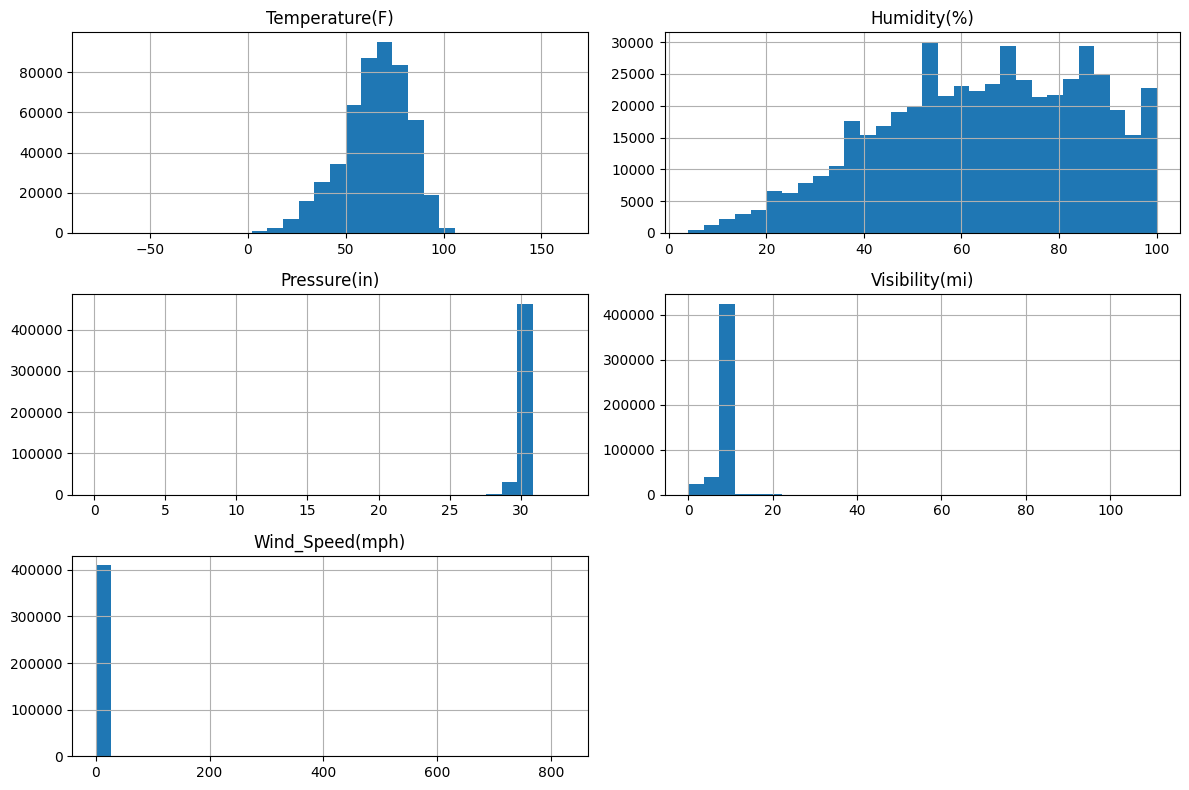

In [14]:
df[cols_na].hist(bins=30, figsize=(12,8))
plt.tight_layout()
plt.savefig("salida/histogramas.png", dpi=300, bbox_inches='tight')
plt.show()

In [15]:
df['Wind_Speed(mph)'].describe()

count    410960.000000
mean          8.913004
std           5.414922
min           0.000000
25%           5.800000
50%           8.100000
75%          11.500000
max         822.800000
Name: Wind_Speed(mph), dtype: float64

In [16]:
df.dtypes

Start_Lat          float64
Start_Lng          float64
Distance(mi)       float64
Temperature(F)     float64
Humidity(%)        float64
Pressure(in)       float64
Visibility(mi)     float64
Wind_Speed(mph)    float64
Bump                  bool
Crossing              bool
Give_Way              bool
Junction              bool
Railway               bool
Roundabout            bool
Stop                  bool
Traffic_Signal        bool
dtype: object

In [17]:
cols_numericas = [
    'Distance(mi)',
    'Temperature(F)',
    'Humidity(%)',
    'Pressure(in)',
    'Visibility(mi)',
    'Wind_Speed(mph)'
]

In [18]:
df[cols_numericas].describe()

,Distance(mi),Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph)
count,500000.000000,492750.000000,492085.000000,494261.000000,489461.000000,410960.000000
mean,0.065294,64.668092,64.529433,30.004807,9.227911,8.913004
std,0.782881,16.877594,21.387837,0.242343,2.140192,5.414922
min,0.000000,-77.800000,4.000000,0.120000,0.000000,0.000000
25%,0.000000,55.000000,49.000000,29.900000,10.000000,5.800000
50%,0.010000,66.200000,66.000000,30.000000,10.000000,8.100000
75%,0.010000,77.000000,82.000000,30.110000,10.000000,11.500000
max,90.370003,161.600000,100.000000,33.040000,111.000000,822.800000


In [19]:
df['Wind_Speed(mph)'].sort_values(ascending=False).head(20)

114580    822.8
114588    822.8
114633    822.8
114640    822.8
114647    822.8
64265     241.7
491511    174.9
134892    162.3
17802     142.7
288672    127.7
247668    126.6
247672    126.6
247674    126.6
478379    126.6
247720    126.6
113147    123.1
113131    123.1
113098    100.1
113839    100.1
113099    100.1
Name: Wind_Speed(mph), dtype: float64

#https://www.google.com/search?q=mayor+velocidad+del+viento+en+usa+a+partir+de+2016&sca_esv=c8cadf7be06f0f41&rlz=1C5CHFA_enMX1190MX1190&sxsrf=ANbL-n7vpcTq4vmWW4UiHqq_0qqUZc_xsw%3A1772169192629&ei=6CehafWQJtHFp84P577YyQc&biw=1102&bih=620&ved=0ahUKEwj1pNXZ9PiSAxXR4skDHWcfNnkQ4dUDCBE&uact=5&oq=mayor+velocidad+del+viento+en+usa+a+partir+de+2016&gs_lp=Egxnd3Mtd2l6LXNlcnAiMm1heW9yIHZlbG9jaWRhZCBkZWwgdmllbnRvIGVuIHVzYSBhIHBhcnRpciBkZSAyMDE2MgUQIRigATIFECEYoAEyBRAhGKABMgUQIRigATIFECEYnwVIniFQ0whY5B9wAXgBkAEAmAGgA6ABgBWqAQkwLjguNS4wLjG4AQPIAQD4AQGYAg-gArUVwgIKEAAYsAMY1gQYR8ICBBAhGBWYAwCIBgGQBgiSBwkxLjguNS4wLjGgB4BesgcJMC44LjUuMC4xuAeuFcIHBjEuMTIuMsgHHYAIAA&sclient=gws-wiz-serp


In [20]:
df.loc[df['Wind_Speed(mph)'] > 250, 'Wind_Speed(mph)'] = np.nan

In [21]:
df['Wind_Speed(mph)'].sort_values(ascending=False).head(20)

64265     241.7
491511    174.9
134892    162.3
17802     142.7
288672    127.7
478379    126.6
247668    126.6
247672    126.6
247674    126.6
247720    126.6
113147    123.1
113131    123.1
113839    100.1
113099    100.1
113098    100.1
403987     97.8
464793     76.0
25414      73.6
25418      73.6
25423      73.6
Name: Wind_Speed(mph), dtype: float64

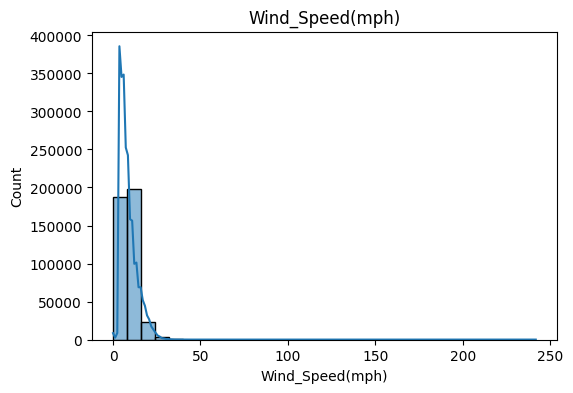

In [22]:
plt.figure(figsize=(6,4))
sns.histplot(df['Wind_Speed(mph)'], bins=30, kde=True)
plt.title('Wind_Speed(mph)')
plt.show()

In [23]:
#Se utilizó imputación con la mediana debido a la distribución de los datos

In [24]:
df['Wind_Speed(mph)'] = df['Wind_Speed(mph)'].fillna(df['Wind_Speed(mph)'].median())

In [25]:
df['Visibility(mi)'].sort_values(ascending=False).head(20)

301379    111.0
301376    111.0
220819    105.0
455821     80.0
314388     80.0
9080       80.0
340044     80.0
316592     80.0
396531     80.0
399505     40.0
338045     40.0
2903       40.0
454486     40.0
13706      40.0
15969      40.0
33043      30.0
794        30.0
14938      30.0
217856     30.0
35993      30.0
Name: Visibility(mi), dtype: float64

In [26]:
#df["Visibility(mi)"].describe()

In [27]:
df["Visibility(mi)"].quantile(0.99)

np.float64(10.0)

In [28]:
#Se truncaron los datos a un valor límite de 10 ya que los valores por encima de 10mi ya parecen indicar errores de typo
df["Visibility(mi)"] = df["Visibility(mi)"].clip(upper=10)
df["Visibility(mi)"].describe()

count    489461.000000
mean          9.202974
std           2.058144
min           0.000000
25%          10.000000
50%          10.000000
75%          10.000000
max          10.000000
Name: Visibility(mi), dtype: float64

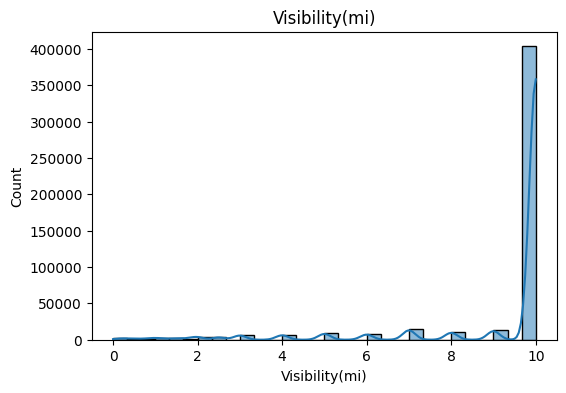

In [29]:
plt.figure(figsize=(6,4))
sns.histplot(df["Visibility(mi)"], bins=30, kde=True)
plt.title('Visibility(mi)')
plt.show()

In [30]:
df['Visibility(mi)'] = df['Visibility(mi)'].fillna(df['Visibility(mi)'].median())

In [31]:
df['Pressure(in)'].sort_values(ascending=False).head(10)

16339     33.04
16340     33.04
325937    31.03
325932    31.03
385786    30.98
325915    30.96
325914    30.96
368980    30.95
368981    30.95
325952    30.95
Name: Pressure(in), dtype: float64

In [32]:
df['Pressure(in)'].sort_values(ascending=True).head(10)

116969     0.12
87260      2.98
62146      2.99
159001     3.00
158998     3.00
3752       3.01
53525      3.04
53535      3.04
432459     9.90
82282     20.04
Name: Pressure(in), dtype: float64

In [33]:
#df["Pressure(in)"].describe()

In [34]:
df["Pressure(in)"].quantile([0.01, 0.99])

0.01    29.37
0.99    30.52
Name: Pressure(in), dtype: float64

In [35]:
df.loc[
    (df["Pressure(in)"] < 20) | 
    (df["Pressure(in)"] > 32),
    "Pressure(in)"
] = np.nan

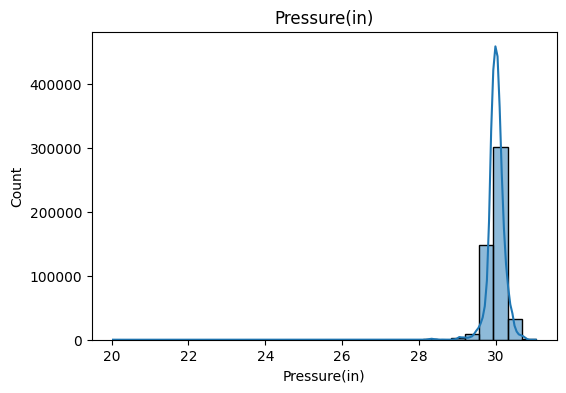

In [36]:
plt.figure(figsize=(6,4))
sns.histplot(df["Pressure(in)"], bins=30, kde=True)
plt.title('Pressure(in)')
plt.show()

In [37]:
df['Pressure(in)'] = df['Pressure(in)'].fillna(df['Pressure(in)'].median())

In [38]:
#df["Humidity(%)"].describe()

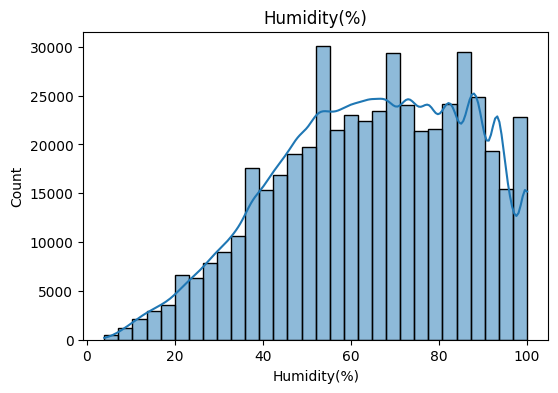

In [39]:
plt.figure(figsize=(6,4))
sns.histplot(df["Humidity(%)"], bins=30, kde=True)
plt.title('Humidity(%)')
plt.show()

In [40]:
df['Humidity(%)'] = df['Humidity(%)'].fillna(df['Humidity(%)'].median())

In [41]:
#df["Temperature(F)"].describe()

In [42]:
df["Temperature(F)"].quantile([0.01, 0.99])

0.01    19.9
0.99    95.0
Name: Temperature(F), dtype: float64

In [43]:
df['Temperature(F)'].sort_values(ascending=True).head(10)

201311   -77.8
201309   -77.8
200834   -77.8
200806   -77.8
168326   -13.0
168327   -13.0
168330   -11.9
168332   -11.9
168333   -11.9
168352    -9.0
Name: Temperature(F), dtype: float64

In [44]:
df['Temperature(F)'].sort_values(ascending=False).head(10)

292016    161.6
273850    143.6
292035    140.0
273856    136.4
291717    136.4
273857    136.4
290241    132.8
177676    132.6
363906    123.8
289289    122.0
Name: Temperature(F), dtype: float64

In [45]:
df.loc[
    (df["Temperature(F)"] < -14) | 
    (df["Temperature(F)"] > 139),
    "Temperature(F)"
] = np.nan

In [46]:
df['Temperature(F)'] = df['Temperature(F)'].fillna(df['Temperature(F)'].median())

In [47]:
df.isna().sum()

Start_Lat          0
Start_Lng          0
Distance(mi)       0
Temperature(F)     0
Humidity(%)        0
Pressure(in)       0
Visibility(mi)     0
Wind_Speed(mph)    0
Bump               0
Crossing           0
Give_Way           0
Junction           0
Railway            0
Roundabout         0
Stop               0
Traffic_Signal     0
dtype: int64

In [48]:
df.dtypes

Start_Lat          float64
Start_Lng          float64
Distance(mi)       float64
Temperature(F)     float64
Humidity(%)        float64
Pressure(in)       float64
Visibility(mi)     float64
Wind_Speed(mph)    float64
Bump                  bool
Crossing              bool
Give_Way              bool
Junction              bool
Railway               bool
Roundabout            bool
Stop                  bool
Traffic_Signal        bool
dtype: object

In [49]:
bool_cols = [
            'Bump', 'Crossing', 'Give_Way', 'Junction',
            'Railway', 'Roundabout', 'Stop', 'Traffic_Signal'
            ]
df[bool_cols] = df[bool_cols].astype(int)
df.dtypes

Start_Lat          float64
Start_Lng          float64
Distance(mi)       float64
Temperature(F)     float64
Humidity(%)        float64
Pressure(in)       float64
Visibility(mi)     float64
Wind_Speed(mph)    float64
Bump                 int64
Crossing             int64
Give_Way             int64
Junction             int64
Railway              int64
Roundabout           int64
Stop                 int64
Traffic_Signal       int64
dtype: object

In [50]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled

array([[ 0.78206452,  0.74020637, -0.07062936, ..., -0.00583105,
        -0.18026279, -0.54627958],
       [ 0.79456572,  0.807355  , -0.07062936, ..., -0.00583105,
        -0.18026279, -0.54627958],
       [ 0.62269985,  0.74163491, -0.07062936, ..., -0.00583105,
        -0.18026279,  1.83056449],
       ...,
       [-0.37633171,  0.85881907, -0.08340271, ..., -0.00583105,
        -0.18026279, -0.54627958],
       [-0.28598832,  0.79691307, -0.08340271, ..., -0.00583105,
        -0.18026279, -0.54627958],
       [-0.42884243,  0.72208245, -0.08340271, ..., -0.00583105,
        -0.18026279, -0.54627958]], shape=(500000, 16))

In [51]:
X_scaled_c = np.ascontiguousarray(X_scaled, dtype=np.float64)

pca = PCA(n_components=0.90, svd_solver="full", random_state=42)
X_pca = pca.fit_transform(X_scaled_c)

print("Forma de X_pca:", X_pca.shape)

Forma de X_pca: (500000, 13)


In [ ]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=150,
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom"
)

labels_hdb = clusterer.fit_predict(X_pca)

unique, counts = np.unique(labels_hdb, return_counts=True)
print("num clusters (sin ruido):", (unique != -1).sum())
print("porcentaje de ruido:", (labels_hdb == -1).mean())

num clusters (sin ruido): 114
porcentaje de ruido: 0.297134


In [53]:
mask = labels_hdb != -1
X_eval = X_pca[mask]
y_eval = labels_hdb[mask]
unique, counts = np.unique(y_eval, return_counts=True)
print("Min cluster size:", counts.min())

Min cluster size: 153


In [54]:
print("Davies-Bouldin:", davies_bouldin_score(X_eval, y_eval))
print("Calinski-Harabasz:", calinski_harabasz_score(X_eval, y_eval))

Davies-Bouldin: 2.3315311226339848
Calinski-Harabasz: 6961.44537968596


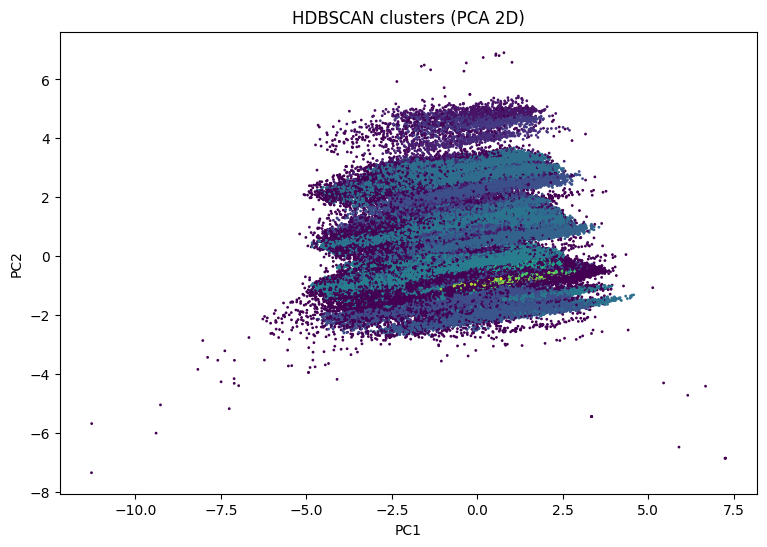

In [55]:
pca2 = PCA(n_components=2, random_state=42)
X2 = pca2.fit_transform(X_pca)

plt.figure(figsize=(9,6))
plt.scatter(X2[:,0], X2[:,1], c=labels_hdb, s=1)
plt.title("HDBSCAN clusters (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

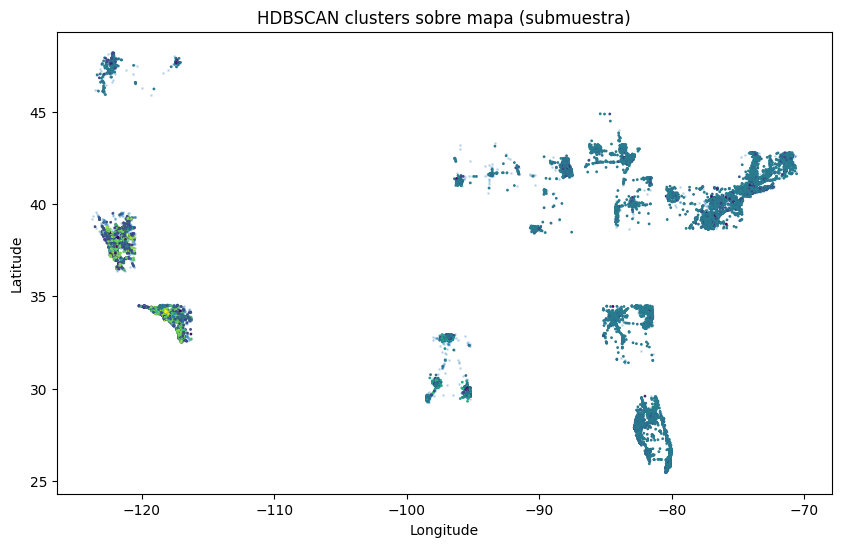

In [ ]:
rng = np.random.default_rng(42)
idx = rng.choice(df.shape[0], size=60000, replace=False)

lat = df.iloc[idx]["Start_Lat"].to_numpy()
lng = df.iloc[idx]["Start_Lng"].to_numpy()
lab = labels_hdb[idx]

plt.figure(figsize=(10,6))
noise = lab == -1

plt.scatter(lng[noise], lat[noise], s=1, alpha=0.2)

plt.scatter(lng[~noise], lat[~noise], c=lab[~noise], s=1)

plt.title("HDBSCAN clusters sobre mapa (submuestra)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.savefig("salida/hdbscan.png", dpi=300)
plt.show()

In [57]:
cols_2 = [
 'Distance(mi)','Temperature(F)',
 'Humidity(%)','Pressure(in)','Visibility(mi)','Wind_Speed(mph)',
 'Bump','Crossing','Give_Way','Junction','Railway',
 'Roundabout','Stop','Traffic_Signal'
]

df_2 = df[cols_2]

In [58]:
X_2 = StandardScaler().fit_transform(df_2)
X_2 = np.asarray(X_2, dtype=np.float64)

pca_ng = PCA(n_components=0.90, svd_solver="full", random_state=42)
X_2_pca = pca_ng.fit_transform(X_2)

print("Shape:", X_2_pca.shape)
print("Varianza:", pca_ng.explained_variance_ratio_.sum())

Shape: (500000, 12)
Varianza: 0.9299889688529347


In [59]:
clusterer_2 = hdbscan.HDBSCAN(
    min_cluster_size=150,
    min_samples=5
)

labels_no_geo = clusterer_2.fit_predict(X_2_pca)

print("Clusters:", len(set(labels_no_geo)) - (1 if -1 in labels_no_geo else 0))
print("Ruido %:", (labels_no_geo == -1).mean())

Clusters: 134
Ruido %: 0.456806


In [60]:
rng = np.random.default_rng(42)
idx_ward = rng.choice(X_pca.shape[0], size=25000, replace=False)

X_ward = X_pca[idx_ward]

In [61]:
for k in range(2, 11):
    ward = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels_w = ward.fit_predict(X_ward)
    
    sil = silhouette_score(X_ward, labels_w)
    db  = davies_bouldin_score(X_ward, labels_w)
    ch  = calinski_harabasz_score(X_ward, labels_w)
    
    print(f"k={k} | Sil={sil:.4f} | DB={db:.4f} | CH={ch:.2f}")

k=2 | Sil=0.9741 | DB=0.0277 | CH=4389.11
k=3 | Sil=0.6864 | DB=0.3322 | CH=3544.23
k=4 | Sil=0.1637 | DB=1.2154 | CH=3383.40
k=5 | Sil=0.1928 | DB=1.1451 | CH=3386.85
k=6 | Sil=0.1953 | DB=0.9562 | CH=3521.36
k=7 | Sil=0.2290 | DB=0.9683 | CH=3732.10
k=8 | Sil=0.2127 | DB=0.8694 | CH=4049.90
k=9 | Sil=0.2008 | DB=1.0517 | CH=4288.21
k=10 | Sil=0.2247 | DB=0.9742 | CH=4520.59


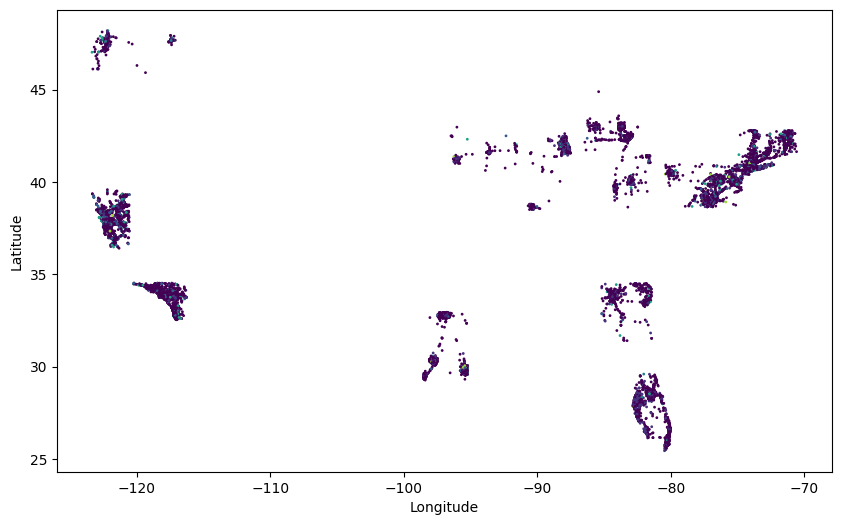

In [62]:
lat_w = df.iloc[idx_ward]["Start_Lat"].to_numpy()
lng_w = df.iloc[idx_ward]["Start_Lng"].to_numpy()

ward = AgglomerativeClustering(n_clusters=8, linkage='ward')
labels_w = ward.fit_predict(X_ward)

plt.figure(figsize=(10,6))
plt.scatter(lng_w, lat_w, c=labels_w, s=1)
#plt.title("Ward k=8")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.savefig("salida/ward.png", dpi=300)
plt.show()

In [63]:
df.columns

Index(['Start_Lat', 'Start_Lng', 'Distance(mi)', 'Temperature(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'Railway', 'Roundabout',
       'Stop', 'Traffic_Signal'],
      dtype='object')

In [64]:
df2 = df.copy()
df2['cluster'] = labels_hdb
df2.groupby('cluster').mean()

,Start_Lat,Start_Lng,Distance(mi),Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Bump,Crossing,Give_Way,Junction,Railway,Roundabout,Stop,Traffic_Signal
cluster,,,,,,,,,,,,,,,,
-1,35.265345,-106.773530,0.204159,63.188405,62.920669,29.976660,8.701489,9.513998,0.000963,0.062645,0.00315,0.012930,0.004624,0.000114,0.018746,0.079250
0,37.867572,-98.324125,0.055702,62.196930,68.258772,30.001798,9.054825,8.774561,0.000000,0.289474,1.00000,0.008772,0.000000,0.000000,1.000000,0.083333
1,37.060314,-102.565215,0.003839,63.542654,62.199052,30.027014,9.079621,8.982464,0.000000,0.909953,0.00000,0.004739,1.000000,0.000000,1.000000,0.061611
2,34.903786,-113.082532,0.016827,64.452209,67.317269,29.996426,9.442972,8.338554,0.000000,0.072289,0.00000,1.000000,1.000000,0.000000,0.000000,0.028112
3,37.884123,-94.445240,0.070125,63.553750,60.266667,30.012625,9.226250,7.862917,0.000000,0.170833,0.00000,1.000000,0.000000,0.000000,1.000000,0.020833
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,33.985598,-118.219965,0.002922,63.753896,83.512987,29.947078,10.000000,8.100000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
110,33.997274,-118.074157,0.006732,60.796078,72.156863,29.980915,10.000000,8.100000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
111,33.996039,-118.180474,0.003486,64.402721,77.998299,29.935714,10.000000,8.100000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000


In [65]:
df2['cluster'].value_counts().head(10)

cluster
-1     148567
 47    130269
 43     29049
 40     24801
 29     16461
 42     15224
 25     11791
 35     11185
 39     10141
 27      5710
Name: count, dtype: int64

In [66]:
df2[df2['cluster'] == 47].mean()

Start_Lat          37.257210
Start_Lng         -80.208557
Distance(mi)        0.005639
Temperature(F)     62.172670
Humidity(%)        67.431384
Pressure(in)       30.046347
Visibility(mi)      9.208893
Wind_Speed(mph)     8.740524
Bump                0.000000
Crossing            0.000000
Give_Way            0.000000
Junction            0.000000
Railway             0.000000
Roundabout          0.000000
Stop                0.000000
Traffic_Signal      0.000000
cluster            47.000000
dtype: float64

In [67]:
df2.groupby('cluster')['Traffic_Signal'].mean().sort_values(ascending=False).head()

cluster
34    1.0
19    1.0
17    1.0
16    1.0
15    1.0
Name: Traffic_Signal, dtype: float64

In [68]:
df2[df2['cluster'] == 34].mean()

Start_Lat           47.544558
Start_Lng         -120.795583
Distance(mi)         0.004760
Temperature(F)      58.812915
Humidity(%)         65.686347
Pressure(in)        30.043911
Visibility(mi)       9.992620
Wind_Speed(mph)      7.276015
Bump                 0.000000
Crossing             0.000000
Give_Way             0.000000
Junction             0.000000
Railway              0.000000
Roundabout           0.000000
Stop                 0.000000
Traffic_Signal       1.000000
cluster             34.000000
dtype: float64

In [69]:
df_ward = df.iloc[idx_ward].copy()
df_ward['ward'] = labels_w

In [70]:
df_ward.groupby('ward').mean()

,Start_Lat,Start_Lng,Distance(mi),Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Bump,Crossing,Give_Way,Junction,Railway,Roundabout,Stop,Traffic_Signal
ward,,,,,,,,,,,,,,,,
0,35.979203,-98.055143,0.085129,63.973772,64.958819,29.999561,9.031883,8.929644,0.0,0.024361,0.0,0.001218,0.000000,0.0,0.000000,0.058987
1,35.333862,-93.302197,0.011316,67.257963,63.201303,30.036333,9.845037,8.256286,0.0,0.532465,0.0,0.000000,0.000000,0.0,0.000000,0.899743
2,37.033778,-103.168795,0.038511,63.926605,63.858372,29.986082,9.165586,8.907876,0.0,0.011251,0.0,1.000000,0.000000,0.0,0.000000,0.027796
3,36.668346,-104.852860,0.006277,66.040693,63.727273,30.014156,9.493506,8.794805,0.0,0.554113,0.0,0.043290,1.000000,0.0,0.043290,0.367965
4,36.723807,-99.754819,0.015789,62.516688,65.614081,30.005567,9.158931,8.964537,0.0,0.325945,0.0,0.007823,0.000000,0.0,1.000000,0.061278
5,32.253428,-106.296806,0.001429,69.542857,57.571429,30.030000,8.571429,11.714286,1.0,0.428571,0.0,0.000000,0.000000,0.0,0.428571,0.000000
6,35.181116,-89.482913,0.006494,64.125862,67.471264,30.063161,9.150575,9.104598,0.0,0.321839,1.0,0.028736,0.011494,0.0,0.086207,0.603448
7,38.435045,-101.971604,0.000000,46.500000,87.500000,30.130000,10.000000,8.650000,0.0,0.500000,0.0,0.000000,0.000000,1.0,0.000000,0.000000


In [71]:
df_ward.groupby('ward')[['Start_Lat','Start_Lng']].mean()

,Start_Lat,Start_Lng
ward,,
0,35.979203,-98.055143
1,35.333862,-93.302197
2,37.033778,-103.168795
3,36.668346,-104.852860
4,36.723807,-99.754819
5,32.253428,-106.296806
6,35.181116,-89.482913
7,38.435045,-101.971604


In [72]:
df_ward.groupby('ward')[[
    'Traffic_Signal',
    'Crossing',
    'Junction'
]].mean()

,Traffic_Signal,Crossing,Junction
ward,,,
0,0.058987,0.024361,0.001218
1,0.899743,0.532465,0.000000
2,0.027796,0.011251,1.000000
3,0.367965,0.554113,0.043290
4,0.061278,0.325945,0.007823
5,0.000000,0.428571,0.000000
6,0.603448,0.321839,0.028736
7,0.000000,0.500000,0.000000


In [73]:
print("Proceso finalizado.")

Proceso finalizado.
